<a href="https://colab.research.google.com/github/Bokenasubi-T/pomacea-distribution-jp/blob/main/notebooks/05_japan_mask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. Mask WorldClim rasters to the land area of Japan

- Input: `data/wc2.1_30s_bio_{1,6,12}_japan.tif` (created by `04_WorldClim.ipynb`), GADM 4.1 national boundary of Japan (level 0)
- Output: `data/wc2.1_30s_bio_{1,6,12}_japan_land.tif`

- Purpose: Remove cells outside Japan (e.g. the Korean Peninsula and parts of China and Russia) from the rectangular crop. The masked rasters are used for background points and prediction maps of the species distribution model.
- Note: Coastal cells that the boundary only partly covers are kept (`all_touched=True`), because many records are located along the coast.
- Note: GADM data may not be redistributed, so the boundary file is downloaded in this notebook and is not stored in the repository. The masked rasters are also kept on Google Drive only because of their size.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

# Project folders on Google Drive
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/pomacea"
DATA_DIR = f"{BASE_DIR}/data"

Mounted at /content/drive


In [2]:
# Install library for reading and writing raster data (geopandas is preinstalled on Colab)
!pip install rasterio

In [3]:
# GADM 4.1, Japan, level 0 (national boundary). Redistribution is not allowed, so keep it out of Git.
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_JPN_0.json"
gadm_path = f"{DATA_DIR}/gadm41_JPN_0.json"
!wget -nc -P "{DATA_DIR}" {GADM_URL}

--2026-09-30 08:57:50--  https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_JPN_0.json
Resolving geodata.ucdavis.edu (geodata.ucdavis.edu)... 128.120.146.30
Connecting to geodata.ucdavis.edu (geodata.ucdavis.edu)|128.120.146.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 941412 (919K) [application/json]
Saving to: ‘/content/drive/MyDrive/Colab Notebooks/pomacea/data/gadm41_JPN_0.json’

gadm41_JPN_0.json   100%[===================>] 919.35K  1015KB/s    in 0.9s    

2026-09-30 08:57:51 (1015 KB/s) - ‘/content/drive/MyDrive/Colab Notebooks/pomacea/data/gadm41_JPN_0.json’ saved [941412/941412]



EPSG:4326 (1, 3)


<Axes: >

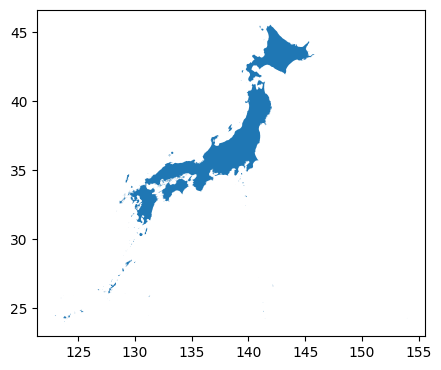

In [4]:
import geopandas as gpd

japan = gpd.read_file(gadm_path)
print(japan.crs, japan.shape)
japan.plot(figsize=(5, 5))

In [5]:
import numpy as np
import rasterio
from rasterio.mask import mask

for v in [1, 6, 12]:
    src_path = f"{DATA_DIR}/wc2.1_30s_bio_{v}_japan.tif"
    out_path = f"{DATA_DIR}/wc2.1_30s_bio_{v}_japan_land.tif"

    with rasterio.open(src_path) as src:
        shapes = japan.to_crs(src.crs).geometry  # make sure both use the same coordinate system
        # all_touched=True keeps coastal cells that the boundary only partly covers
        out, transform = mask(src, shapes, crop=True, all_touched=True, filled=True)
        profile = src.profile.copy()
        profile.update(height=out.shape[1], width=out.shape[2], transform=transform,
                       compress="deflate", tiled=True, blockxsize=256, blockysize=256)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(out)

    n_land = int((out[0] != profile["nodata"]).sum())
    print(f"bio{v}: {n_land:,} land cells -> {out_path}")

bio1: 548,035 land cells -> /content/drive/MyDrive/Colab Notebooks/pomacea/data/wc2.1_30s_bio_1_japan_land.tif
bio6: 548,035 land cells -> /content/drive/MyDrive/Colab Notebooks/pomacea/data/wc2.1_30s_bio_6_japan_land.tif
bio12: 548,035 land cells -> /content/drive/MyDrive/Colab Notebooks/pomacea/data/wc2.1_30s_bio_12_japan_land.tif
